# 02 — Radial Distribution (Free Vortex)

**Purpose:** Extend the meanline result spanwise using the free-vortex law (r·Cθ = const). Verify that De Haller and Lieblein DF stay within limits at every radial station from hub to tip. Confirm hub loading is not excessive.

**Inputs:** Design point from `01_meanline_sweep.ipynb`.

**Outputs:**
- Spanwise distributions of β₁, β₂, α₂, Δβ, W₂/W₁, DF
- Flag of any station where DF > 0.45
- Confirmation that the free-vortex law is a valid approximation

**References:** Dixon & Hall (2014) Ch. 6; Lieblein et al. (1953) NACA RM E53D01.

In [1]:
# Cell 0 — repository path setup
# ─────────────────────────────────────────────────────────────────────────────
# Insert this as the FIRST cell in every notebook.
# Works identically in:
#   • VS Code Jupyter (cwd = workspace root or notebook folder)
#   • JupyterLab browser (JPY_SESSION_NAME points to the .ipynb file)
#   • Classic Jupyter Notebook
#   • Any working directory — does not depend on where the server was started
#
# After this cell runs, both import styles work everywhere:
#   from src.meanline import meanline_analysis   ← old style, unchanged
#   from meanline import meanline_analysis        ← new style, also fine
# ─────────────────────────────────────────────────────────────────────────────

import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

warnings.filterwarnings("ignore")


def _find_repo_root(marker: str = "src") -> Path:
    """
    Find the repository root by walking up from multiple candidate
    starting points.  Tries in order:

    1. Parent of the notebook file itself  (JPY_SESSION_NAME, set by
       JupyterLab — the most reliable anchor in a browser session).
    2. Current working directory  (works when cwd == repo root, e.g.
       VS Code with workspace opened at repo root).
    3. Home directory subtree  (last resort fallback).

    Returns the first directory that contains a `src/` subdirectory.
    """
    jpy = os.environ.get("JPY_SESSION_NAME", "")
    candidates = [
        Path(jpy).parent if jpy else None,   # JupyterLab: notebook dir
        Path.cwd(),                           # VS Code / terminal launch
        Path.home(),                          # last resort
    ]

    seen: set[str] = set()
    for start in candidates:
        if start is None:
            continue
        try:
            p = start.resolve()
        except Exception:
            continue
        for _ in range(8):
            key = str(p)
            if key in seen:
                break
            seen.add(key)
            if (p / marker).is_dir():
                return p
            if p.parent == p:
                break
            p = p.parent

    raise FileNotFoundError(
        f"Cannot find repo root — no '{marker}/' directory found.\n"
        f"  JPY_SESSION_NAME : {jpy!r}\n"
        f"  cwd              : {Path.cwd()}\n"
        f"  Searched up to   : {list(seen)}\n"
        f"Tip: make sure src/ exists in the repository root."
    )


REPO_ROOT = _find_repo_root()
SRC_PATH  = REPO_ROOT / "src"

# Both styles resolve correctly once both paths are on sys.path
for _p in [str(SRC_PATH), str(REPO_ROOT)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

# ── Project imports ────────────────────────────────────────────────────────────
from src.constants import gamma, R, Cp, T0_in, P0_in  # old style — works
from src.meanline  import meanline_analysis, omega_from_RPM
from src.radial    import free_vortex

try:
    from src.plotting import plot_design_maps, plot_velocity_triangles, plot_radial
except Exception:
    pass  # plotting.py needs pandas; skip if not installed

from src.igv import (
    igv_geometry,
    meanline_with_igv,
    print_igv_summary,
    print_rotor_summary,
)
from src.bellmouth import (
    bellmouth_design,
    outer_bellmouth_profile,
    centerbody_profile,
    print_bellmouth_summary,
)
from src.shaft import (
    rotor_mass,
    shaft_sizing,
    bearing_selection,
    campbell_data,
    print_shaft_summary,
    print_bearing_summary,
    print_campbell_summary,
)

# ── Matplotlib style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        130,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "font.size":         10,
})

COLORS = {
    "blue":   "#185FA5",
    "teal":   "#1D9E75",
    "coral":  "#D85A30",
    "purple": "#534AB7",
    "amber":  "#BA7517",
    "gray":   "#5F5E5A",
}

# ── Confirmation ───────────────────────────────────────────────────────────────
print(f"Repo root  : {REPO_ROOT}")
print(f"Src path   : {SRC_PATH}")
print(f"Python     : {sys.version.split()[0]}")
print(f"Launch env : {'JupyterLab (JPY_SESSION_NAME)' if os.environ.get('JPY_SESSION_NAME') else 'VS Code / classic Jupyter (cwd)'}")
print("Imports    : OK")

Repo root  : D:\Dev\rotating-rig-design
Src path   : D:\Dev\rotating-rig-design\src
Python     : 3.10.2
Launch env : JupyterLab (JPY_SESSION_NAME)
Imports    : OK


## 1. Design point (from notebook 01)

In [2]:
D_tip = 0.900  # m
N     = 3500   # RPM
PR    = 1.10
eta   = 0.85
nu    = 0.75
phi   = 0.725

res = meanline_analysis(D_tip, N, PR, eta, nu=nu, phi=phi)
print(f'Mean radius  : {res["r_mean"]*1000:.1f} mm')
print(f'Blade height : {res["h_mm"]:.1f} mm')
print(f'ψ = {res["psi"]:.4f}   DH = {res["De_Haller"]:.4f}   P = {res["P_shaft_kW"]:.1f} kW')

Mean radius  : 393.8 mm
Blade height : 112.5 mm
ψ = 0.4514   DH = 0.7361   P = 335.4 kW


## 2. Free-vortex radial distribution

In [3]:
# Rotor mid-span solidity (auto-sized in igv.py; replicate here)
import math
r_mean = res['r_mean']
h      = res['r_tip'] - res['r_hub']
AR     = 1.5
B      = int(math.ceil(2 * math.pi * r_mean * 1.1 * AR / h))
if B % 2 == 0: B += 1
chord_mid = h / AR
pitch_mid = 2 * math.pi * r_mean / B
sigma_mid = chord_mid / pitch_mid

print(f'B = {B} blades,  chord_mid = {chord_mid*1000:.1f} mm,  σ_mid = {sigma_mid:.3f}')

rad = free_vortex(res, n_stations=80, sigma=sigma_mid)

B = 37 blades,  chord_mid = 75.0 mm,  σ_mid = 1.122


## 3. Three-panel radial plot

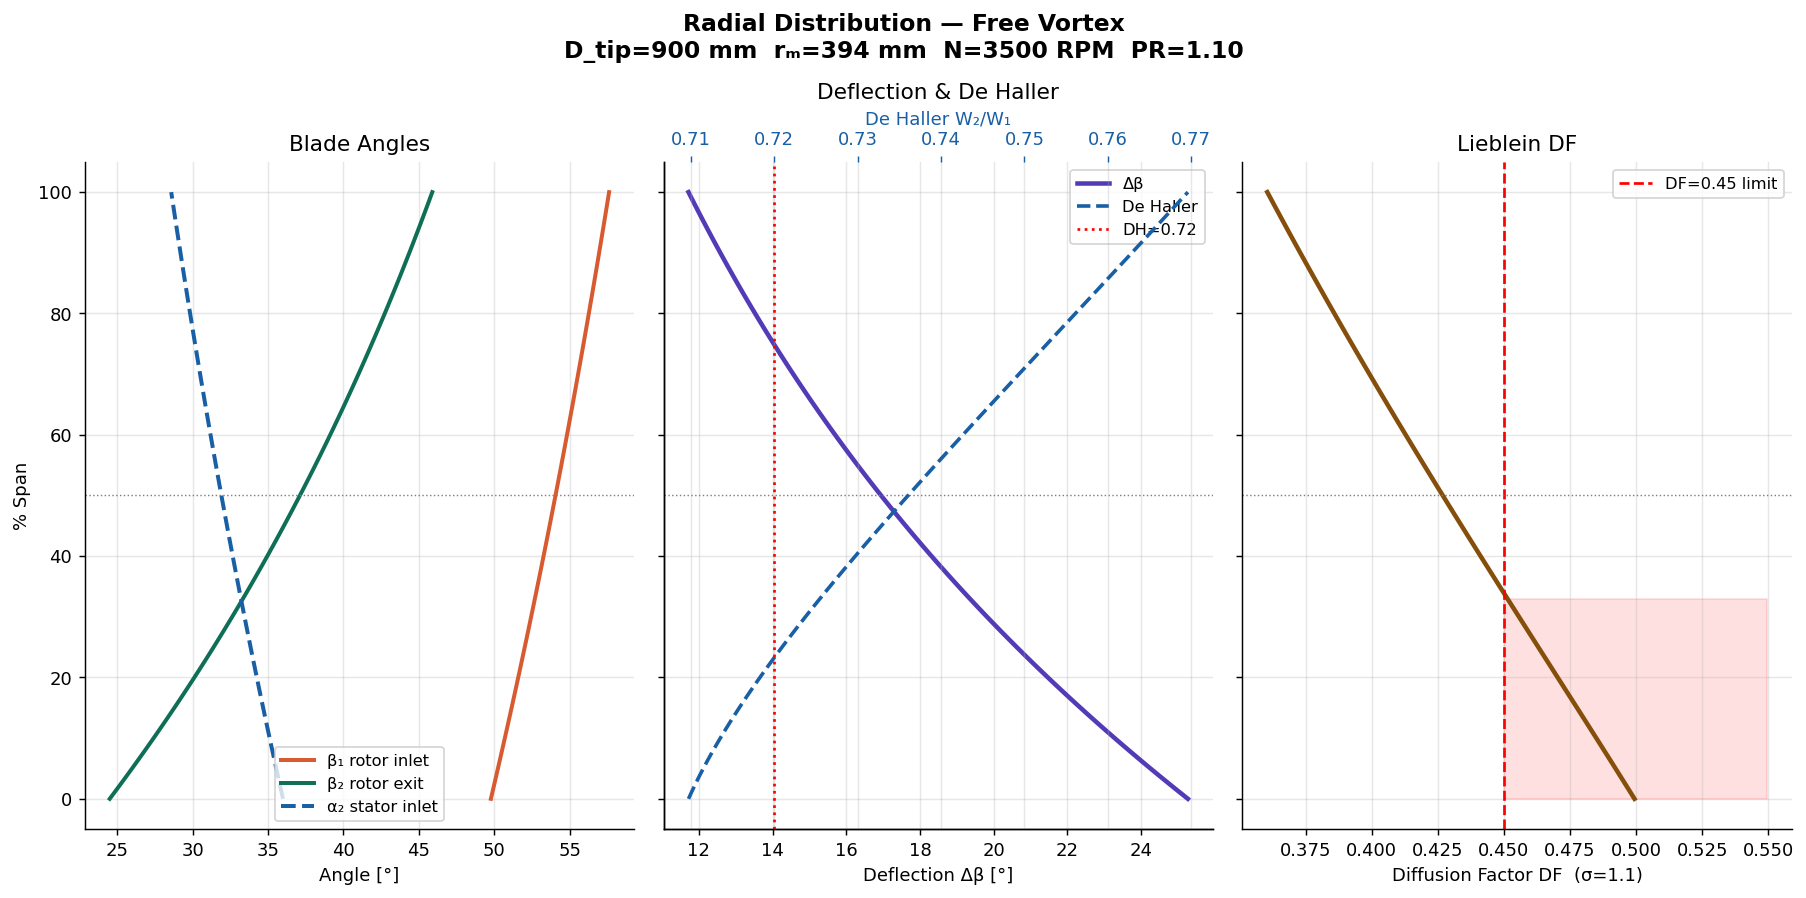

In [4]:
import pathlib
_r = next(p for p in [pathlib.Path.cwd()] + list(pathlib.Path.cwd().parents) if (p / "src").is_dir())
plot_radial(res, rad, save_path=str(_r / "figures" / "02_radial_distribution.png"))

## 4. Tabulate blade angles at key stations

In [5]:
import pandas as pd

# Sample at hub (0%), 25%, 50% (mean), 75%, tip (100%)
idx = [0, 20, 40, 60, 79]
tbl = pd.DataFrame({
    '% span'  : rad['pct_span'][idx].round(1),
    'r [mm]'  : (rad['r'][idx] * 1000).round(1),
    'U [m/s]' : rad['U_r'][idx].round(2),
    'β₁ [°]'  : rad['beta1'][idx].round(2),
    'β₂ [°]'  : rad['beta2'][idx].round(2),
    'Δβ [°]'  : rad['delta_beta'][idx].round(2),
    'α₂ [°]'  : rad['alpha2'][idx].round(2),
    'W₂/W₁'   : rad['DH'][idx].round(4),
    'DF'       : rad['DF'][idx].round(4),
})
print(tbl.to_string(index=False))

 % span  r [mm]  U [m/s]  β₁ [°]  β₂ [°]  Δβ [°]  α₂ [°]  W₂/W₁     DF
    0.0   337.5   123.70   49.77   24.50   25.27   36.00 0.7097 0.4994
   25.3   366.0   134.14   52.05   31.47   20.57   33.82 0.7211 0.4625
   50.6   394.5   144.58   54.11   37.24   16.86   31.86 0.7365 0.4260
   75.9   422.9   155.02   55.98   42.05   13.94   30.10 0.7534 0.3912
  100.0   450.0   164.93   57.61   45.89   11.72   28.58 0.7696 0.3605


## 5. Constraint check — flagged stations

In [6]:
dh_fail  = rad['pct_span'][rad['DH'] < 0.72]
df_fail  = rad['pct_span'][rad['DF'] > 0.45]

print('De Haller < 0.72 at % span:', dh_fail.round(1) if len(dh_fail) else 'None ✓')
print('Lieblein DF > 0.45 at % span:', df_fail.round(1) if len(df_fail) else 'None ✓')

print(f'\nDH range : {rad["DH"].min():.4f} – {rad["DH"].max():.4f}')
print(f'DF range : {rad["DF"].min():.4f} – {rad["DF"].max():.4f}')

De Haller < 0.72 at % span: [ 0.   1.3  2.5  3.8  5.1  6.3  7.6  8.9 10.1 11.4 12.7 13.9 15.2 16.5
 17.7 19.  20.3 21.5 22.8]
Lieblein DF > 0.45 at % span: [ 0.   1.3  2.5  3.8  5.1  6.3  7.6  8.9 10.1 11.4 12.7 13.9 15.2 16.5
 17.7 19.  20.3 21.5 22.8 24.1 25.3 26.6 27.8 29.1 30.4 31.6 32.9]

DH range : 0.7097 – 0.7696
DF range : 0.3605 – 0.4994


## 6. Solidity sensitivity

DF depends on solidity. Check how the hub DF (worst station) moves with σ.

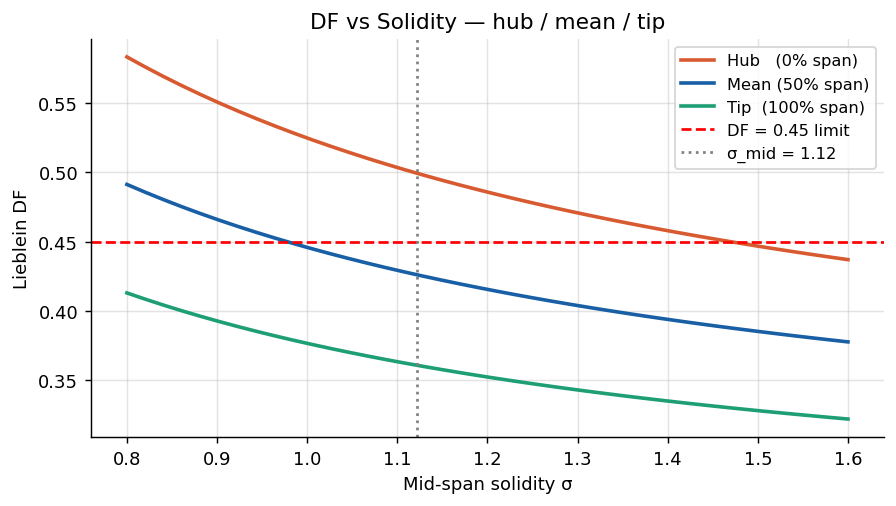

In [7]:
sigma_range = np.linspace(0.8, 1.6, 40)
df_hub   = [free_vortex(res, n_stations=80, sigma=s)['DF'][0]  for s in sigma_range]
df_mean  = [free_vortex(res, n_stations=80, sigma=s)['DF'][40] for s in sigma_range]
df_tip   = [free_vortex(res, n_stations=80, sigma=s)['DF'][-1] for s in sigma_range]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sigma_range, df_hub,  '#D85A30', lw=2, label='Hub   (0% span)')
ax.plot(sigma_range, df_mean, '#185FA5', lw=2, label='Mean (50% span)')
ax.plot(sigma_range, df_tip,  '#1D9E75', lw=2, label='Tip  (100% span)')
ax.axhline(0.45, color='red', ls='--', lw=1.5, label='DF = 0.45 limit')
ax.axvline(sigma_mid, color='gray', ls=':', lw=1.5, label=f'σ_mid = {sigma_mid:.2f}')
ax.set(xlabel='Mid-span solidity σ', ylabel='Lieblein DF',
       title='DF vs Solidity — hub / mean / tip')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig('../figures/02_df_vs_sigma.png', dpi=130, bbox_inches='tight')
plt.show()

---
**Proceed to** `03_igv_design.ipynb`.